# Daily AQI Merge Workflow

This notebook documents how we pulled city-level air quality files from different sources and turned them into one daily dataset for downstream analysis.

## What we are building
A single daily table with at least:
- `date`
- `location`
- `aqi`

We also keep context columns (`city`, `country`, `pm25`, `aqi_method`, `source_dataset`) so later analysis is easier to trace and audit.

## Data source notes
- **India**: already provides daily city-level AQI, so this is mostly a schema cleanup task.
- **USA**: includes AQI and PM2.5 at monitoring-site level; we aggregate those records to city-day.
- **Other Cities**: provides PM2.5, so we convert PM2.5 to AQI using EPA breakpoints.
- **China (Kaggle)**: left out for now because the file has year/month/hour but no day-level timestamp.

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)
sns.set_theme(style='whitegrid')

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
RAW_DIR = PROJECT_ROOT / 'data' / 'raw'
CLEAN_DIR = PROJECT_ROOT / 'data' / 'clean'
CLEAN_DIR.mkdir(parents=True, exist_ok=True)

print('Project root:', PROJECT_ROOT)
print('Raw data dir:', RAW_DIR)
print('Clean data dir:', CLEAN_DIR)


Project root: /workspaces/covid-air-pollution-causal-inference
Raw data dir: /workspaces/covid-air-pollution-causal-inference/data/raw
Clean data dir: /workspaces/covid-air-pollution-causal-inference/data/clean


## 1. Quick inventory of raw data
Before transforming anything, we take a quick inventory so everyone can see what files and source groups are in scope.

In [3]:
raw_files = sorted(RAW_DIR.rglob('*.csv'))
inventory = pd.DataFrame({
    'relative_path': [str(path.relative_to(PROJECT_ROOT)) for path in raw_files],
    'parent_folder': [path.parent.name for path in raw_files],
    'file_name': [path.name for path in raw_files],
})
inventory.head(15)


,relative_path,parent_folder,file_name
0,data/raw/India/Bengaluru_AQIBulletins.csv,India,Bengaluru_AQIBulletins.csv
1,data/raw/India/Delhi_AQIBulletins.csv,India,Delhi_AQIBulletins.csv
2,data/raw/India/Mumbai_AQIBulletins.csv,India,Mumbai_AQIBulletins.csv
3,data/raw/Other Cities/Berlin.csv,Other Cities,Berlin.csv
4,data/raw/Other Cities/London_clean.csv,Other Cities,London_clean.csv
5,data/raw/Other Cities/Mexico_City.csv,Other Cities,Mexico_City.csv
6,data/raw/Other Cities/Paris_clean.csv,Other Cities,Paris_clean.csv
7,data/raw/Other Cities/Sao_Paulo.csv,Other Cities,Sao_Paulo.csv
8,data/raw/Other Cities/Seoul.csv,Other Cities,Seoul.csv
9,data/raw/Other Cities/Tokyo.csv,Other Cities,Tokyo.csv


In [4]:
inventory['top_group'] = inventory['relative_path'].str.split('/').str[2]
inventory['top_group'].value_counts().rename_axis('source_group').to_frame('file_count')


,file_count
source_group,
USA,21
Other Cities,14
India,3
china - Kaggle,1


**Insight:** This inventory check is useful for catching unexpected files early (for example, duplicate exports or naming drift) before they quietly affect the merge.

## 2. Inspect representative schemas
The source files are not standardized, so we inspect one sample from each source to confirm column names and data types before harmonizing.

In [5]:
samples = {
    'India': RAW_DIR / 'India' / 'Delhi_AQIBulletins.csv',
    'USA': RAW_DIR / 'USA' / 'Boston' / 'ad_viz_plotval_data.csv',
    'Other Cities': RAW_DIR / 'Other Cities' / 'cleaned' / 'Berlin_clean.csv',
    'China': RAW_DIR / 'china - Kaggle' / 'air_pollution_china.csv',
}

for name, path in samples.items():
    print(f'\n{name}: {path.name}')
    df = pd.read_csv(path)
    print(df.columns.tolist())
    display(df.head(2))



India: Delhi_AQIBulletins.csv
['date', 'City', 'No. Stations', 'Air Quality', 'Index Value', 'Prominent Pollutant']


,date,City,No. Stations,Air Quality,Index Value,Prominent Pollutant
0,2015-05-01,Delhi,NaN,Poor,221,O3
1,2015-05-02,Delhi,NaN,Poor,238,"O3, PM2.5"



USA: ad_viz_plotval_data.csv
['Date', 'Source', 'Site ID', 'POC', 'Daily Mean PM2.5 Concentration', 'Units', 'Daily AQI Value', 'Local Site Name', 'Daily Obs Count', 'Percent Complete', 'AQS Parameter Code', 'AQS Parameter Description', 'Method Code', 'Method Description', 'CBSA Code', 'CBSA Name', 'State FIPS Code', 'State', 'County FIPS Code', 'County', 'Site Latitude', 'Site Longitude']


,Date,Source,Site ID,POC,Daily Mean PM2.5 Concentration,Units,Daily AQI Value,Local Site Name,Daily Obs Count,Percent Complete,AQS Parameter Code,AQS Parameter Description,Method Code,Method Description,CBSA Code,CBSA Name,State FIPS Code,State,County FIPS Code,County,Site Latitude,Site Longitude
0,01/01/2019,AQS,250092006,3,3.2,ug/m3 LC,18,LYNN WATER TREATMENT PLANT,1,100.0,88101,PM2.5 - Local Conditions,170,Met One BAM-1020 Mass Monitor w/VSCC,14460,"Boston-Cambridge-Newton, MA-NH",25,Massachusetts,9,Essex,42.474642,-70.970816
1,01/02/2019,AQS,250092006,3,3.2,ug/m3 LC,18,LYNN WATER TREATMENT PLANT,1,100.0,88101,PM2.5 - Local Conditions,170,Met One BAM-1020 Mass Monitor w/VSCC,14460,"Boston-Cambridge-Newton, MA-NH",25,Massachusetts,9,Essex,42.474642,-70.970816



Other Cities: Berlin_clean.csv
['date', 'city', 'pm25']


,date,city,pm25
0,2016-11-20,Berlin,17.1125
1,2016-11-21,Berlin,27.3625



China: air_pollution_china.csv
['PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (µg/m³)', 'SO2 (µg/m³)', 'CO (mg/m³)', 'O3 (µg/m³)', 'Temperature (°C)', 'Humidity (%)', 'Wind Speed (m/s)', 'Wind Direction (°)', 'Pressure (hPa)', 'Precipitation (mm)', 'Visibility (km)', 'AQI', 'Season', 'City', 'Latitude', 'Longitude', 'Day of Week', 'Hour', 'Month', 'Year', 'Weather Condition', 'Station ID']


,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (µg/m³),SO2 (µg/m³),CO (mg/m³),O3 (µg/m³),Temperature (°C),Humidity (%),Wind Speed (m/s),Wind Direction (°),Pressure (hPa),Precipitation (mm),Visibility (km),AQI,Season,City,Latitude,Longitude,Day of Week,Hour,Month,Year,Weather Condition,Station ID
0,94.437337,253.533160,57.759232,3.676372,2.568404,116.383653,4.578449,43.406082,7.861799,266.338889,990.780654,30.034919,18.270028,4,Spring,Shenzhen,36.268122,112.199251,Sunday,2,7,2016,Haze,58
1,194.174790,165.605024,75.117403,22.243199,1.528823,178.428560,37.332250,27.446097,9.742233,27.266465,994.616334,47.454277,2.049126,48,Spring,Shanghai,48.629080,105.238302,Monday,17,11,2017,Cloudy,18


**Insight:** This comparison step tells us where schema mismatch is likely to happen. It also keeps our transformation logic explicit instead of relying on assumptions about column names.

## 3. Helper functions
This section defines shared helpers for name normalization and PM2.5-to-AQI conversion so the cleaning logic stays consistent across sources.

In [6]:
CITY_RENAMES = {
    'San Fran': 'San Francisco',
    'Sao_Paulo': 'Sao Paulo',
    'Mexico_City': 'Mexico City',
}

COUNTRY_MAP = {
    'Berlin': 'Germany',
    'London': 'United Kingdom',
    'Mexico City': 'Mexico',
    'Paris': 'France',
    'Sao Paulo': 'Brazil',
    'Seoul': 'South Korea',
    'Tokyo': 'Japan',
}

PM25_BREAKPOINTS = [
    (0.0, 12.0, 0, 50),
    (12.1, 35.4, 51, 100),
    (35.5, 55.4, 101, 150),
    (55.5, 150.4, 151, 200),
    (150.5, 250.4, 201, 300),
    (250.5, 350.4, 301, 400),
    (350.5, 500.4, 401, 500),
]

def normalize_city(city: str) -> str:
    city = str(city).strip()
    return CITY_RENAMES.get(city, city)

def pm25_to_aqi(pm25):
    if pd.isna(pm25):
        return np.nan
    pm25 = float(pm25)
    if pm25 < 0:
        return np.nan
    for c_lo, c_hi, i_lo, i_hi in PM25_BREAKPOINTS:
        if c_lo <= pm25 <= c_hi:
            aqi = ((i_hi - i_lo) / (c_hi - c_lo)) * (pm25 - c_lo) + i_lo
            return round(aqi)
    return 500 if pm25 > 500.4 else np.nan


**Insight:** Keeping conversion logic in one function reduces drift across cells. If we later change AQI methodology, we only need to update one place.

## 4. Build source-specific cleaned tables
Each source is cleaned into the same target schema first. That makes the final concat and aggregation much safer and easier to debug.

In [7]:
# India: daily city AQI already available.
india_frames = []
for path in sorted((RAW_DIR / 'India').glob('*.csv')):
    df = pd.read_csv(path)
    cleaned = pd.DataFrame({
        'date': pd.to_datetime(df['date']),
        'city': df['City'].map(normalize_city),
        'country': 'India',
        'location': df['City'].map(normalize_city) + ', India',
        'aqi': pd.to_numeric(df['Index Value'], errors='coerce'),
        'pm25': np.nan,
        'aqi_method': 'provided',
        'source_dataset': 'India AQI Bulletins',
    })
    india_frames.append(cleaned)

india_daily = pd.concat(india_frames, ignore_index=True)
india_daily.head()


,date,city,country,location,aqi,pm25,aqi_method,source_dataset
0,2015-05-02,Bengaluru,India,"Bengaluru, India",132,NaN,provided,India AQI Bulletins
1,2015-05-03,Bengaluru,India,"Bengaluru, India",49,NaN,provided,India AQI Bulletins
2,2015-05-04,Bengaluru,India,"Bengaluru, India",46,NaN,provided,India AQI Bulletins
3,2015-05-05,Bengaluru,India,"Bengaluru, India",229,NaN,provided,India AQI Bulletins
4,2015-05-06,Bengaluru,India,"Bengaluru, India",90,NaN,provided,India AQI Bulletins


In [8]:
# USA: daily AQI/PM2.5 per monitoring site, later aggregated to city-day.
usa_frames = []
for city_dir in sorted((RAW_DIR / 'USA').iterdir()):
    if not city_dir.is_dir():
        continue
    city_name = normalize_city(city_dir.name)
    for path in sorted(city_dir.glob('*.csv')):
        df = pd.read_csv(path)
        cleaned = pd.DataFrame({
            'date': pd.to_datetime(df['Date'], format='%m/%d/%Y'),
            'city': city_name,
            'country': 'USA',
            'location': f'{city_name}, USA',
            'aqi': pd.to_numeric(df['Daily AQI Value'], errors='coerce'),
            'pm25': pd.to_numeric(df['Daily Mean PM2.5 Concentration'], errors='coerce'),
            'aqi_method': 'provided',
            'source_dataset': 'USA EPA AQS',
        })
        usa_frames.append(cleaned)

usa_daily_raw = pd.concat(usa_frames, ignore_index=True)
usa_daily_raw.head()


,date,city,country,location,aqi,pm25,aqi_method,source_dataset
0,2020-01-01,Boston,USA,"Boston, USA",21,3.7,provided,USA EPA AQS
1,2020-01-02,Boston,USA,"Boston, USA",36,6.5,provided,USA EPA AQS
2,2020-01-03,Boston,USA,"Boston, USA",52,9.9,provided,USA EPA AQS
3,2020-01-04,Boston,USA,"Boston, USA",53,10.2,provided,USA EPA AQS
4,2020-01-05,Boston,USA,"Boston, USA",14,2.6,provided,USA EPA AQS


In [9]:
# Other Cities: cleaned files provide daily PM2.5; AQI is derived.
other_city_frames = []
for path in sorted((RAW_DIR / 'Other Cities' / 'cleaned').glob('*_clean.csv')):
    df = pd.read_csv(path)
    city_name = normalize_city(path.stem.replace('_clean', '').replace('_', ' '))
    country = COUNTRY_MAP[city_name]
    cleaned = pd.DataFrame({
        'date': pd.to_datetime(df['date']),
        'city': city_name,
        'country': country,
        'location': f'{city_name}, {country}',
        'aqi': pd.to_numeric(df['pm25'], errors='coerce').map(pm25_to_aqi),
        'pm25': pd.to_numeric(df['pm25'], errors='coerce'),
        'aqi_method': 'derived_from_pm25',
        'source_dataset': 'Other Cities PM2.5',
    })
    other_city_frames.append(cleaned)

other_cities_daily = pd.concat(other_city_frames, ignore_index=True)
other_cities_daily.head()


,date,city,country,location,aqi,pm25,aqi_method,source_dataset
0,2016-11-20,Berlin,Germany,"Berlin, Germany",62.0,17.112500,derived_from_pm25,Other Cities PM2.5
1,2016-11-21,Berlin,Germany,"Berlin, Germany",83.0,27.362500,derived_from_pm25,Other Cities PM2.5
2,2016-11-22,Berlin,Germany,"Berlin, Germany",87.0,29.349999,derived_from_pm25,Other Cities PM2.5
3,2016-11-24,Berlin,Germany,"Berlin, Germany",49.0,11.650000,derived_from_pm25,Other Cities PM2.5
4,2016-11-25,Berlin,Germany,"Berlin, Germany",59.0,15.945000,derived_from_pm25,Other Cities PM2.5


**Insight:** Splitting cleaning by source keeps source-specific assumptions local while still producing a common schema. That balance helped keep the workflow readable and robust.

## 5. Combine and aggregate to one row per city-day
This is the actual merge point. Because USA data can have multiple monitoring-site rows per city-day, we aggregate numeric fields to city-day averages.

In [10]:
combined = pd.concat([india_daily, usa_daily_raw, other_cities_daily], ignore_index=True)

merged_daily = (
    combined
    .groupby(['date', 'city', 'country', 'location'], as_index=False)
    .agg(
        aqi=('aqi', 'mean'),
        pm25=('pm25', 'mean'),
        aqi_method=('aqi_method', lambda x: ';'.join(sorted(set(x.dropna())))),
        source_dataset=('source_dataset', lambda x: ';'.join(sorted(set(x.dropna())))),
        raw_row_count=('city', 'size')
    )
    .sort_values(['date', 'country', 'city'])
    .reset_index(drop=True)
)

merged_daily['aqi'] = merged_daily['aqi'].round(2)
merged_daily['pm25'] = merged_daily['pm25'].round(4)
merged_daily.head(10)


,date,city,country,location,aqi,pm25,aqi_method,source_dataset,raw_row_count
0,2015-05-01,Delhi,India,"Delhi, India",221.0,NaN,provided,India AQI Bulletins,1
1,2015-05-02,Bengaluru,India,"Bengaluru, India",132.0,NaN,provided,India AQI Bulletins,1
2,2015-05-02,Delhi,India,"Delhi, India",238.0,NaN,provided,India AQI Bulletins,1
3,2015-05-03,Bengaluru,India,"Bengaluru, India",49.0,NaN,provided,India AQI Bulletins,1
4,2015-05-03,Delhi,India,"Delhi, India",259.0,NaN,provided,India AQI Bulletins,1
5,2015-05-04,Bengaluru,India,"Bengaluru, India",46.0,NaN,provided,India AQI Bulletins,1
6,2015-05-04,Delhi,India,"Delhi, India",289.0,NaN,provided,India AQI Bulletins,1
7,2015-05-05,Bengaluru,India,"Bengaluru, India",229.0,NaN,provided,India AQI Bulletins,1
8,2015-05-05,Delhi,India,"Delhi, India",311.0,NaN,provided,India AQI Bulletins,1
9,2015-05-06,Bengaluru,India,"Bengaluru, India",90.0,NaN,provided,India AQI Bulletins,1


**Insight:** The `raw_row_count` field is especially useful for QA because it shows how many source records were collapsed into each final row.

## 6. Basic validation and quick analysis
These checks are here so a teammate can quickly judge coverage, distribution, and whether the merged output looks reasonable before export.

In [11]:
print('Merged rows:', len(merged_daily))
print('Unique locations:', merged_daily['location'].nunique())
print('Date range:', merged_daily['date'].min().date(), 'to', merged_daily['date'].max().date())

merged_daily[['aqi', 'pm25', 'raw_row_count']].describe()


Merged rows: 28519
Unique locations: 17
Date range: 2015-05-01 to 2026-03-18


,aqi,pm25,raw_row_count
count,28424.000000,19371.000000,28519.000000
mean,81.023712,37.021216,5.391564
std,85.701495,210.567148,8.505083
min,0.000000,-1.000000,1.000000
25%,35.000000,6.118000,1.000000
50%,53.655000,9.228700,1.000000
75%,83.000000,14.612050,9.000000
max,500.000000,7163.875000,50.000000


In [12]:
merged_daily.groupby('country').agg(
    rows=('location', 'size'),
    locations=('location', 'nunique'),
    mean_aqi=('aqi', 'mean')
).sort_values('rows', ascending=False)


,rows,locations,mean_aqi
country,,,
India,9147,3,134.436974
USA,7672,7,41.072341
United Kingdom,2483,1,39.412217
France,2441,1,43.422594
Germany,2274,1,42.777974
Mexico,1813,1,67.778516
Japan,962,1,36.459770
South Korea,868,1,292.414747
Brazil,859,1,57.781434


In [13]:
location_counts = merged_daily['location'].value_counts().sort_values(ascending=False)
location_counts.head(15)


location
Delhi, India              3143
Bengaluru, India          3120
Mumbai, India             2884
London, United Kingdom    2483
Paris, France             2441
Berlin, Germany           2274
Mexico City, Mexico       1813
Boston, USA               1096
Chicago, USA              1096
Houston, USA              1096
Los Angeles, USA          1096
New York, USA             1096
Phoenix, USA              1096
San Francisco, USA        1096
Tokyo, Japan               962
Name: count, dtype: int64

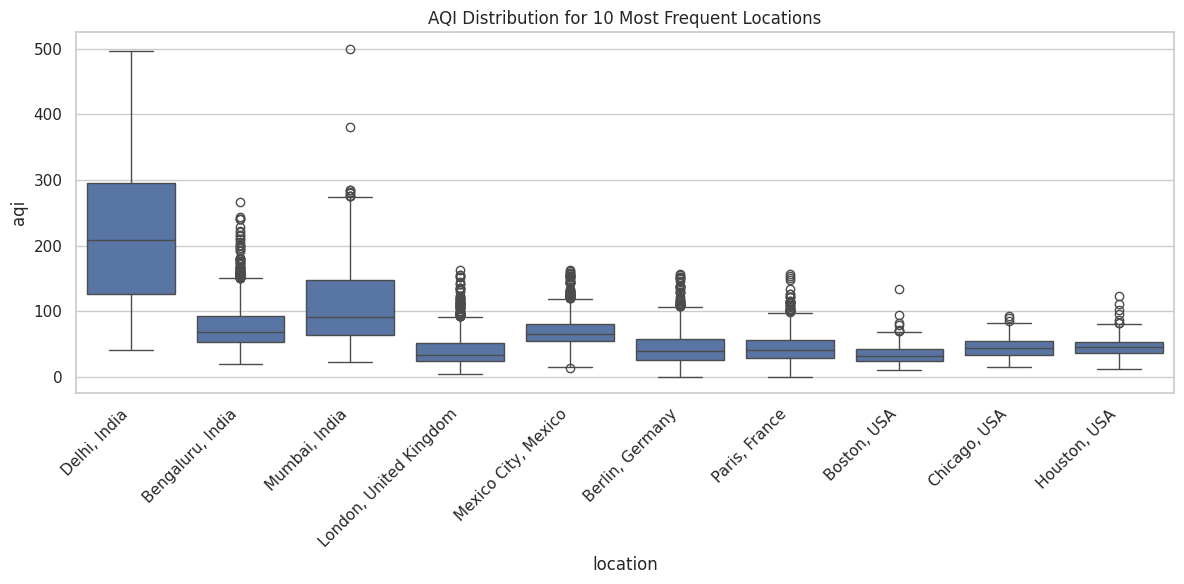

In [14]:
plt.figure(figsize=(12, 6))
top_locations = merged_daily['location'].value_counts().head(10).index
sns.boxplot(
    data=merged_daily[merged_daily['location'].isin(top_locations)],
    x='location',
    y='aqi'
)
plt.xticks(rotation=45, ha='right')
plt.title('AQI Distribution for 10 Most Frequent Locations')
plt.tight_layout()
plt.show()


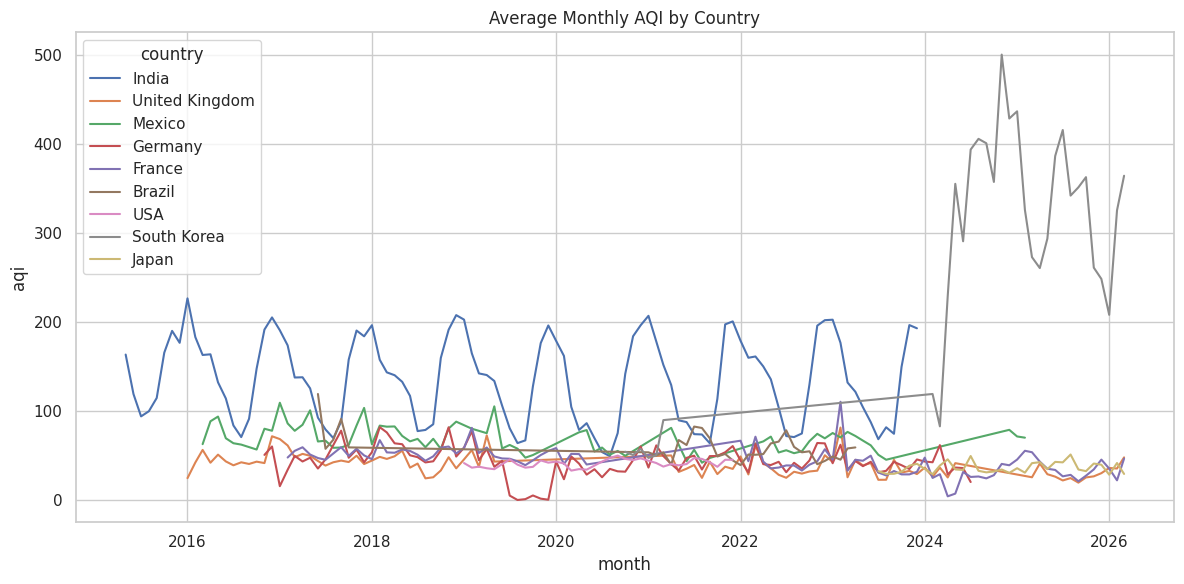

In [15]:
monthly_trend = (
    merged_daily.assign(month=merged_daily['date'].dt.to_period('M').dt.to_timestamp())
    .groupby(['month', 'country'], as_index=False)['aqi']
    .mean()
)

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_trend, x='month', y='aqi', hue='country')
plt.title('Average Monthly AQI by Country')
plt.tight_layout()
plt.show()


**Insight:** The boxplot and monthly trend are not meant as final causal results. They act as sanity checks to spot outliers, imbalance, and broad temporal patterns before modeling.

## 7. Save the merged dataset
Saving our merged dataset.

In [16]:
output_path = CLEAN_DIR / 'merged_daily_aqi.csv'
merged_daily.to_csv(output_path, index=False)
print('Saved merged dataset to:', output_path)


Saved merged dataset to: /workspaces/covid-air-pollution-causal-inference/data/clean/merged_daily_aqi.csv


## Notes
- China is still excluded from the daily merge until we have a reliable day-level timestamp in that source.